# Capstone -Credit Card Fraud Detection
> **Dataset:** [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
> **Goal:** To demonstrate the end-to-end application of the machine learning lifecycle—including problem framing, data preprocessing, modelling, evaluation and result communication on a real-world, industry-relevant dataset of choice.

---
# Table of Contents

1. [Introduction](#introduction)  
2. [Pre-processing Section](#pre-processing-section)  
3. [Import Libraries & Global Settings](#import-libraries--global-settings)  
4. [Data Structure](#load-dataset)  
5. [Summary Statistics](#summary-statistics)
6. [Target Class Distribution](#target-class-distribution)  
7. [Missing Values and Duplicate Records](#missing-values)  
8. [Feature Distributions](#feature-distributions)
9. [Outlier and Anomaly Detection](#outlier-and-anomaly-detection)
10. [Correlation Analysis](#correlation-analysis)   
11. [Feature Engineering and Scaling](#feature-engineering-and-scaling)   
12. [Pre-processing Summary Report](#pre-processing-summary-report)  
13. [Processing Section](#processing-section)  
14. [Methodology - SMOTE vs Class Weight](#methodology---smote-vs-class-weight)  
15. [Anomaly Detection](#anomaly-detection)   
16. [Results - AUPRC Comparison Table](#results---auprc-comparison-table)
17. [Interpretability - SHAP Analysis](#interpretability---shap-analysis)   
18. [Business Cost Analysis & Production Recommendations](#business-cost-analysis--production-recommendations)
19. [Bias and Fairness Analysis](#bias-and-fairness-analysis)
20. [Addressing Known Model Limitations](#addressing-known-model-limitations)
21. [Conclusion on Fairness Analysis](#conclusion-on-fairness-analysis)   
22. [Cross-Validation and Robustness Check](#cross-validation-and-robustness-check)    
23. [Overfitting Diagnostics](#overfitting-diagnostics)
24. [Conclusion and Production Recommendations](#conclusion-and-production-recommendations)  
25. [Github Profile & Upload](#github-profile--upload)  
26. [Deployment (Optional)](#deployment-optional)





<a name="introduction"></a>
## Introduction

Credit card fraud costs the global financial industry billions of dollars annually. According to the [Nilson Report](https://nilsonreport.com/newsletters/1232/), global card fraud losses exceeded thirty two  billion dollars in 2021 and are projected to suprass $40 billion by 2027.

The core challenge is asymmetric: there are two types of errors,but their business costs are wildly different.

Error Type:

*   False Negative (FN) -A fraudulent transaction is predicted as legitimate
*   False Positive (FP) -A legitimate transaction is blocked

Business Cost:

*   Full transaction loss +chargeback fee (~\$25 - \$100) + customer trust damage
*   Customer friction, potential churn (~\$5-\$10 per declined transaction)


False Negatives are typically 5-20X more costly than False Positives. This asymmetry directly shapes our choice of:

*   Evaluation metric: AUPRC (Area Under the Precision-Recall Curve) instead of AUC-ROC, because AUPRC is far more sensitive to performance on the minority (fraud) class.
*   Imbalance strategy: Both SMOTE and Class Weights, with the business cost driving the final model selection.

*   Decision threshold: Tuned post-training to favor recall (catching fraud) over precision.














<a name="pre-processing-section"></a>
#Data Pre-processing

## Import Libraries & Global Settings

In [ ]:

# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Imbalance handling ────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Models ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    f1_score
)

# ── Interpretability ──────────────────────────────────────────────────────────
import shap

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})
FRAUD_COLOR   = '#E74C3C'
LEGIT_COLOR   = '#2ECC71'
NEUTRAL_COLOR = '#3498DB'

print("✅ Libraries loaded.")

<a name="load-dataset"></a>
# Load the Dataset

In [ ]:
df = pd.read_csv('/content/raw_creditcard.csv')
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

# Dataset Structure

In [ ]:
# ── Schema ──────────────────────────────────────────────────────────────────
print("=" * 60)
print(" COLUMN INFO")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print(" DATA TYPES SUMMARY")
print("=" * 60)
print(df.dtypes.value_counts())

print("\n" + "=" * 60)
print(" COLUMN NAMES")
print("=" * 60)
print(list(df.columns))

<a name="summary-statistics"></a>
# Summary Statistics

In [ ]:
desc = df.describe().T
desc['skewness'] = df.skew()
desc['kurtosis'] = df.kurtosis()
desc['cv%'] = (desc['std'] / desc['mean'].abs() * 100).round(1)  # coefficient of variation

print("=" * 60)
print(" EXTENDED SUMMARY STATISTICS")
print("=" * 60)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
display(desc)

<a name="target-class-distribution"></a>
# Target Class Distribution

In [ ]:
counts = df['Class'].value_counts()
pcts   = df['Class'].value_counts(normalize=True) * 100

print("=" * 40)
print(" CLASS DISTRIBUTION")
print("=" * 40)
summary = pd.DataFrame({'Count': counts, 'Percentage (%)': pcts.round(4)})
summary.index = ['Legitimate (0)', 'Fraud (1)']
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate', 'Fraud'], counts.values,
            color=[LEGIT_COLOR, FRAUD_COLOR], edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'],
            colors=[LEGIT_COLOR, FRAUD_COLOR],
            autopct='%1.4f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Share (%)')

plt.suptitle('⚠️  Severely Imbalanced Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a name="missing-values"></a>
# Missing Values

In [ ]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing (%)':   (df.isnull().sum() / len(df) * 100).round(4)
})
missing = missing[missing['Missing Count'] > 0]

if missing.empty:
    print("✅ No missing values found in any column.")
else:
    print(f"⚠️  {len(missing)} column(s) with missing values:")
    display(missing)

    # Heatmap of nulls
    plt.figure(figsize=(14, 3))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
                cmap='Reds', xticklabels=True)
    plt.title('Missing Value Heatmap')
    plt.tight_layout()
    plt.show()

## Duplicate Records

In [ ]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found : {n_dupes:,}  ({n_dupes/len(df)*100:.4f}%)")

if n_dupes > 0:
    print("\nSample duplicate rows:")
    display(df[df.duplicated(keep=False)].head(10))

    # Check fraud rate in duplicates
    dup_fraud = df[df.duplicated(keep=False)]['Class'].mean() * 100
    print(f"Fraud rate in duplicates: {dup_fraud:.2f}%")

    # Remove duplicates
    df_clean = df.drop_duplicates().reset_index(drop=True)
    print(f"\nShape after removing duplicates: {df_clean.shape}")
else:
    df_clean = df.copy()
    print("✅ No duplicate rows found.")

<a name="feature-distributions"></a>
# Feature Distributions

In [ ]:
# ── PCA components V1–V28 ────────────────────────────────────────────────────
v_cols = [c for c in df.columns if c.startswith('V')]

fig, axes = plt.subplots(7, 4, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(v_cols):
    ax = axes[i]
    fraud_vals = df[df['Class'] == 1][col]
    legit_vals = df[df['Class'] == 0][col]

    ax.hist(legit_vals, bins=60, alpha=0.5, color=LEGIT_COLOR,
            label='Legit', density=True)
    ax.hist(fraud_vals, bins=60, alpha=0.7, color=FRAUD_COLOR,
            label='Fraud', density=True)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)

    skew_val = df[col].skew()
    ax.text(0.97, 0.95, f'skew={skew_val:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=7, color='gray')

axes[0].legend(fontsize=8)
fig.suptitle('Distribution of PCA Features (V1–V28) — Fraud vs Legit',
             fontsize=15, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

In [ ]:
# ── Time & Amount distributions ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Time — overall
axes[0, 0].hist(df['Time'] / 3600, bins=80, color=NEUTRAL_COLOR, edgecolor='white', linewidth=0.3)
axes[0, 0].set_title('Transaction Time (hours)')
axes[0, 0].set_xlabel('Hours from first transaction')
axes[0, 0].set_ylabel('Count')

# Time — fraud vs legit
axes[0, 1].hist(df[df['Class'] == 0]['Time'] / 3600, bins=80, alpha=0.5,
                color=LEGIT_COLOR, label='Legit', density=True)
axes[0, 1].hist(df[df['Class'] == 1]['Time'] / 3600, bins=80, alpha=0.7,
                color=FRAUD_COLOR, label='Fraud', density=True)
axes[0, 1].set_title('Time Distribution — Fraud vs Legit')
axes[0, 1].set_xlabel('Hours')
axes[0, 1].legend()

# Amount — log scale
axes[1, 0].hist(np.log1p(df[df['Class'] == 0]['Amount']), bins=80,
                alpha=0.5, color=LEGIT_COLOR, label='Legit', density=True)
axes[1, 0].hist(np.log1p(df[df['Class'] == 1]['Amount']), bins=80,
                alpha=0.7, color=FRAUD_COLOR, label='Fraud', density=True)
axes[1, 0].set_title('Transaction Amount — log1p scale')
axes[1, 0].set_xlabel('log1p(Amount)')
axes[1, 0].legend()

# Amount — box plots by class
bp_data = [df[df['Class'] == 0]['Amount'], df[df['Class'] == 1]['Amount']]
bp = axes[1, 1].boxplot(bp_data, patch_artist=True, notch=True,
                         labels=['Legit', 'Fraud'])
for patch, color in zip(bp['boxes'], [LEGIT_COLOR, FRAUD_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_title('Amount Box Plot by Class')
axes[1, 1].set_ylabel('Amount ($)')
axes[1, 1].set_yscale('log')

plt.suptitle('Time & Amount Deep Dive', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<a name="outlier-and-anomaly-detection"></a>
# Outlier & Anomaly Detection

In [ ]:
# ── IQR-based outlier count per column ──────────────────────────────────────
outlier_report = {}
for col in df.select_dtypes(include=[np.number]).columns:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR   # 3×IQR = extreme outliers
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {
        'Q1': round(Q1, 4), 'Q3': round(Q3, 4), 'IQR': round(IQR, 4),
        'Lower Fence (3×IQR)': round(lower, 4),
        'Upper Fence (3×IQR)': round(upper, 4),
        'Outlier Count': n_out,
        'Outlier %': round(n_out / len(df) * 100, 4)
    }

outlier_df = pd.DataFrame(outlier_report).T.sort_values('Outlier Count', ascending=False)
print("=" * 60)
print(" TOP 15 COLUMNS BY OUTLIER COUNT (3×IQR rule)")
print("=" * 60)
display(outlier_df.head(15))

In [ ]:
# ── Z-score extreme values ───────────────────────────────────────────────────
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))
# (z_scores > 5).sum() returns a numpy array. Convert it to a pandas Series for sort_values.
extreme_z_counts = (z_scores > 5).sum(axis=0)
extreme_z = pd.Series(extreme_z_counts, index=df.select_dtypes(include=[np.number]).columns)
extreme_z = extreme_z[extreme_z > 0].sort_values(ascending=False)

print("=" * 60)
print(" COLUMNS WITH |Z-SCORE| > 5")
print("=" * 60)
if extreme_z.empty:
    print("None found.")
else:
    print(extreme_z.to_string())

    # Visualise
    fig, ax = plt.subplots(figsize=(10, 4))
    extreme_z.plot(kind='bar', color=FRAUD_COLOR, edgecolor='white', ax=ax)
    ax.set_title('Extreme Outlier Count per Feature (|Z| > 5)', fontweight='bold')
    ax.set_ylabel('Number of rows')
    ax.set_xlabel('Feature')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<a name="correlation-analysis"></a>
# Correlation Analysis

In [ ]:
# ── Full correlation heatmap ─────────────────────────────────────────────────
corr = df.corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle only
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=False, fmt='.2f', linewidths=0.3,
            vmin=-1, vmax=1, ax=ax,
            cbar_kws={'shrink': 0.6})
ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# ── Correlation with target ──────────────────────────────────────────────────
target_corr = corr['Class'].drop('Class').sort_values()

colors = [FRAUD_COLOR if x > 0 else LEGIT_COLOR for x in target_corr]
fig, ax = plt.subplots(figsize=(10, 7))
target_corr.plot(kind='barh', color=colors, edgecolor='white', ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Target (Class)', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print("\nTop 5 POSITIVE correlations with fraud:")
print(target_corr.tail(5).to_string())
print("\nTop 5 NEGATIVE correlations with fraud:")
print(target_corr.head(5).to_string())

<a name="feature-engineering-and-scaling"></a>
#  Feature Engineering & Scaling

In [ ]:
#from sklearn.preprocessing import RobustScaler, StandardScaler
# Scale Amount and Time (V1-V28 are already PCA-transformed)
df_processed = df_clean.copy()

# ── 1. Log-transform Amount (right-skewed) ───────────────────────────────────
df_processed['Amount_log'] = np.log1p(df_processed['Amount'])

# ── 2. Hour-of-day extraction from Time ─────────────────────────────────────
df_processed['Hour'] = (df_processed['Time'] / 3600).astype(int) % 24

# ── 3. Scale Amount and Time with StandardScaler ) ───────────
scaler = StandardScaler()
df_processed[['Amount_scaled', 'Time_scaled']] = scaler.fit_transform(
    df_processed[['Amount', 'Time']])

# ── 4. Drop original unscaled columns ────────────────────────────────────────
df_processed.drop(columns=['Amount', 'Time'], inplace=True)

print("New feature columns added:")
new_cols = ['Amount_log', 'Hour', 'Amount_scaled', 'Time_scaled']
display(df_processed[new_cols].describe())
print(f"\nFinal processed shape: {df_processed.shape}")

<a name="pre-processing-summary-report"></a>
#  Pre-processing Summary Report

In [ ]:
print("=" * 65)
print("  CREDIT CARD FRAUD — PREPROCESSING SUMMARY")
print("=" * 65)
print(f"  Original shape          : {df.shape}")
print(f"  After deduplication     : {df_clean.shape}")
print(f"  Duplicates removed      : {df.shape[0] - df_clean.shape[0]:,}")
print(f"  Missing values          : {df.isnull().sum().sum()}")
print(f"  Fraud transactions      : {(df['Class']==1).sum():,}  ({(df['Class']==1).mean()*100:.4f}%)")
print(f"  Legit transactions      : {(df['Class']==0).sum():,}  ({(df['Class']==0).mean()*100:.4f}%)")
print(f"  Imbalance ratio (0:1)   : {(df['Class']==0).sum() / max((df['Class']==1).sum(), 1):.0f}:1")
print()
print("  Feature Engineering Applied:")
print("    ✔ Amount → log1p transform (Amount_log)")
print("    ✔ Time  → hour-of-day feature (Hour)")
print("    ✔ Amount & Time → RobustScaler (Amount_scaled, Time_scaled)")
print()
print("  ⚠  Next Steps:")
print("    • Handle class imbalance (SMOTE / undersampling / class_weight)")
print("    • Train/Validation/Test split (stratified)")
print("    • Model selection (Logistic Regression, XGBoost, Isolation Forest…)")
print("    • Evaluation via AUC-ROC, F1, Precision-Recall curves")
print("=" * 65)

In [ ]:
# ── Save processed CSV for downstream use ────────────────────────────────────
df_processed.to_csv('/content/creditcard_processed.csv', index=False)
print("✅ Processed dataset saved to /content/creditcard_processed.csv")

<a name="processing-section"></a>
# Processing Section

In [ ]:
df = pd.read_csv('/content/creditcard_processed.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Nulls: {list(df.isnull().sum())}')
df.head()

In [ ]:
# ── Scale Amount and Time (V1-V28 are already PCA-transformed)───────────────────────────────────────────────


X = df.drop(columns=['Class','Amount_log', 'Hour'])
y = df['Class']

# ── 4.2  Stratified split ─────────────────────────────────────────────────────
# Use a held-out test set that is NEVER touched during resampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape[0]:,} rows | Fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)')
print(f'Test  set: {X_test.shape[0]:,}  rows | Fraud: {y_test.sum()}  ({y_test.mean()*100:.3f}%)')
print()
print('⚠️  SMOTE will be applied ONLY on the training set inside the pipeline.')
print('   The test set retains the original imbalance for realistic evaluation.')

<a  name="methodology---smote-vs-class-weight"></a>
# Methodology - SMOTE vs Class Weight


## Methodology - SMOTE vs Class Weights


###Strategy 1 -SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE generates synthetic fraud samples by interpolating between existing minority-class instances in feature space. This creates a balanced training set without simply duplicating rows.


*   Pros: Richer variety of minority samples; works well with linear models that struggle with imbalance.
*   Cons: Can introduce noise if classes overlap; increases training time; must be applied inside a cross-validation fold to prevent data leakage.


###Strategy 2  - Class Weights

Most sklearn models accept a class_weight parameter. Setting class_weight='balanced' automatically scales the loss function so that misclassifying a fraud instance costs ~577X more than misclassifying a legitimate one (proportional to the inverse class frequency).


*   Pros: No synthetic data; faster training; no leakage risk; often superior for tree-based models.
*   Cons: Does not change the feature distribution seen by the model.

Why not just accuracy?

A naive model that labels every transaction as legitimate achieves 99.83% accuracy - yet catches zero frauds. This is why we use AUPRC (Area Under the Precision-Recall Curve) as the primary metric. Unlike AUC-ROC, AUPRC heavily penalizes missing the positive (fraud) class.

###Decision

We train 6 models (3 algorithms × 2 strategies) and compare AUPRC, AUC-ROC, and business-cost-weighted F1 on the held-out test set.





In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# SMOTE models  (imbalanced-learn Pipeline keeps SMOTE inside the training fold)
# ──────────────────────────────────────────────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)

smote_models = {
    'LR + SMOTE': ImbPipeline(steps=[
        ('smote', smote),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'RF + SMOTE': ImbPipeline(steps=[
        ('smote', smote),
        ('clf', RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42))
    ]),
    'XGB + SMOTE': ImbPipeline(steps=[
        ('smote', smote),
        ('clf', XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6,
            use_label_encoder=False, eval_metric='logloss',
            n_jobs=-1, random_state=42
        ))
    ])
}

print('Training SMOTE models...')
for name, pipe in smote_models.items():
    pipe.fit(X_train, y_train)
    print(f'  ✓ {name}')

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# Class-weight models
# ──────────────────────────────────────────────────────────────────────────────
cw_models = {
    'LR + CW': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    'RF + CW': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42
    ),
    'XGB + CW': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # equivalent to 'balanced'
        use_label_encoder=False, eval_metric='logloss',
        n_jobs=-1, random_state=42
    )
}

print('Training Class-Weight models...')
for name, model in cw_models.items():
    model.fit(X_train, y_train)
    print(f'  ✓ {name}')

<a name="anomaly-detection"></a>
# Anomaly Detection

## Anomaly Detection -Isolation Forest

Isolation Forest is an **unsupervised** anomaly detection algorithm. Unlike the supervised models above, it never sees the fraud label during training. It learns what a normal transaction looks like and flags deviations as anomalies.

**Why we include it here?**

In production, Isolation Forest is often used as a first-pass filter, particularly for detecting *new* fraud patterns not yet in the labelled training data.

**Key hyperparameter:** `contamination` - the expected fraction of anomalies. We set it to the observed fraud rate (~0.0017) so the model's threshold aligns with reality.


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# Isolation Forest — Anomaly Detection
# Trains ONLY on legitimate transactions (X_train where y_train == 0)
# This is the purest unsupervised setup: the model never sees a fraud label.
# ──────────────────────────────────────────────────────────────────────────────

fraud_rate = y_train.mean()   # ~0.0017 — used as contamination
print(f'Observed fraud rate in training set: {fraud_rate:.4f} ({fraud_rate*100:.3f}%)')

# Train only on normal transactions
X_train_normal = X_train[y_train == 0]
print(f'Training Isolation Forest on {len(X_train_normal):,} normal transactions...')

iso_forest = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination=fraud_rate,   # align threshold with actual fraud rate
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_normal)
print('✓ Isolation Forest trained')

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# Convert anomaly scores → a pseudo-probability for AUPRC comparison
#
# decision_function() returns raw anomaly scores: more negative = more anomalous.
# We negate and min-max scale to [0, 1] so it's comparable to predict_proba.
# ──────────────────────────────────────────────────────────────────────────────

iso_scores_raw  = iso_forest.decision_function(X_test)   # lower = more anomalous
iso_scores      = -iso_scores_raw                         # flip: higher = more anomalous
iso_scores_norm = (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())

# Hard predictions (1 = anomaly/fraud, -1 = normal → remap to 0/1)
iso_pred_raw = iso_forest.predict(X_test)                # returns -1 (anomaly) or 1 (normal)
iso_pred     = np.where(iso_pred_raw == -1, 1, 0)        # remap: anomaly=1, normal=0

# ── Metrics ───────────────────────────────────────────────────────────────────
iso_auprc   = average_precision_score(y_test, iso_scores_norm)
iso_auc_roc = roc_auc_score(y_test, iso_scores_norm)
cm_iso      = confusion_matrix(y_test, iso_pred)
tn, fp, fn, tp = cm_iso.ravel()
iso_recall  = tp / (tp + fn)
iso_prec    = tp / (tp + fp) if (tp + fp) > 0 else 0
iso_f1      = f1_score(y_test, iso_pred)
iso_biz_cost = fn * 120 + fp * 8   # using same COST_FN/COST_FP as above

print('Isolation Forest — Test Set Results')
print('=' * 45)
print(f'  AUPRC     : {iso_auprc:.4f}')
print(f'  AUC-ROC   : {iso_auc_roc:.4f}')
print(f'  Recall    : {iso_recall:.4f}')
print(f'  Precision : {iso_prec:.4f}')
print(f'  F1        : {iso_f1:.4f}')
print(f'  FN        : {fn}')
print(f'  FP        : {fp}')
print(f'  Biz Cost  : ${iso_biz_cost:,}')
print('=' * 45)
print()
print(classification_report(y_test, iso_pred, target_names=['Legitimate', 'Fraud']))

In [ ]:
# ── Anomaly Score Distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Score distributions by true class
colors = ['#4C72B0', '#DD8452']
for cls, label, color in zip([0, 1], ['Legitimate', 'Fraud'], colors):
    mask = (y_test == cls)
    axes[0].hist(iso_scores_norm[mask], bins=60, alpha=0.6, label=label,
                 color=color, edgecolor='none', density=True)
axes[0].set_xlabel('Normalised Anomaly Score (higher = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].set_title('Isolation Forest: Score Distribution by Class', fontweight='bold')
axes[0].legend()
axes[0].axvline(iso_scores_norm[iso_pred == 1].min(), color='red',
                linestyle='--', linewidth=1, label='Decision boundary')

# PR curve for Isolation Forest
prec_iso, rec_iso, _ = precision_recall_curve(y_test, iso_scores_norm)
axes[1].plot(rec_iso, prec_iso, color='#DD8452', lw=2,
             label=f'Isolation Forest (AP={iso_auprc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Isolation Forest', fontweight='bold')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('fig_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()

# Store for the combined results table
iso_result = {
    'Model': 'Isolation Forest (unsupervised)',
    'AUPRC': round(iso_auprc, 4),
    'AUC-ROC': round(iso_auc_roc, 4),
    'Recall': round(iso_recall, 4),
    'Precision': round(iso_prec, 4),
    'F1': round(iso_f1, 4),
    'FN': fn,
    'FP': fp,
    'Biz Cost ($FN=120, $FP=8)': f'${iso_biz_cost:,}'
}
print('Isolation Forest result stored for combined table ✓')

<a name="results---auprc-comparison-table"></a>
# Results -AUPRC Comparison Table (all Models)

In [ ]:
# ── Evaluate all 6 models ─────────────────────────────────────────────────────
all_models = {**smote_models, **cw_models}
results = []

# Business cost constants (adjust as needed)
COST_FN = 120   # USD: missed fraud (transaction loss + chargeback)
COST_FP = 8     # USD: blocked legit transaction (customer friction)

for name, model in all_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]

    auprc   = average_precision_score(y_test, y_proba)
    auc_roc = roc_auc_score(y_test, y_proba)

    # Threshold optimised for maximum F1 on PR curve
    prec, rec, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
    best_thresh = thresholds[np.argmax(f1_scores[:-1])]
    y_pred = (y_proba >= best_thresh).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1        = f1_score(y_test, y_pred)
    biz_cost  = fn * COST_FN + fp * COST_FP

    results.append({
        'Model': name,
        'AUPRC': round(auprc, 4),
        'AUC-ROC': round(auc_roc, 4),
        'Recall': round(recall, 4),
        'Precision': round(precision, 4),
        'F1': round(f1, 4),
        'FN': fn,
        'FP': fp,
        f'Biz Cost ($FN={COST_FN}, $FP={COST_FP})': f'${biz_cost:,}'
    })

# Append the Isolation Forest result
results.append(iso_result)

results_df = pd.DataFrame(results).sort_values('AUPRC', ascending=False).reset_index(drop=True)

print('=' * 100)
print('MODEL COMPARISON TABLE — Supervised + Anomaly Detection (sorted by AUPRC ↓)')
print('=' * 100)
print(results_df.to_string(index=False))
print('=' * 100)
print()
print('📝 Note: Isolation Forest is unsupervised — it never uses fraud labels during training.')
print('         Its AUPRC reflects anomaly-score ranking quality, not learned class boundaries.')

In [ ]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = sns.color_palette('muted', n_colors=7)
models  = results_df['Model']

# AUPRC bar chart
bars = axes[0].barh(models, results_df['AUPRC'], color=palette, edgecolor='white')
axes[0].set_xlabel('AUPRC')
axes[0].set_title('AUPRC by Model & Strategy', fontweight='bold')
axes[0].set_xlim(0, 1)
for bar, val in zip(bars, results_df['AUPRC']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
                 va='center', fontsize=9)

# Precision-Recall curves — supervised models
for (name, model), color in zip(all_models.items(), palette):
    y_proba = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color, lw=1.8)

# Add Isolation Forest PR curve
prec_iso, rec_iso, _ = precision_recall_curve(y_test, iso_scores_norm)
axes[1].plot(rec_iso, prec_iso, label=f'Isolation Forest (AP={iso_auprc:.3f})',
             color=palette[6], lw=2, linestyle='--')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Models', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=7)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Confusion matrices for top 2 models ──────────────────────────────────────
top2 = results_df.head(2)['Model'].tolist()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name in zip(axes, top2):
    model   = all_models[name]
    y_proba = model.predict_proba(X_test)[:, 1]
    prec, rec, thresholds = precision_recall_curve(y_test, y_proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    best_thresh = thresholds[np.argmax(f1s[:-1])]
    y_pred = (y_proba >= best_thresh).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Legit', 'Pred: Fraud'],
                yticklabels=['True: Legit', 'True: Fraud'])
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

<a name="interpretability---shap-analysis"></a>
# Interpretability -SHAP Analysis

## Interpretability -SHAP Analysis

SHAP (SHapley Additive exPlanations) decomposes each prediction into the contribution of each feature, grounded in cooperative game theory. We use the best-performing model (`XGB + CW`) for interpretability analysis.

### Global Feature Importance (Bar Plot — Mean |SHAP|)

The bar plot shows the average absolute SHAP value for each feature across all test transactions — this is the global picture of which features matter most overall.



*   V14 -Dominant fraud signal — strongest single predictor by a wide margin
*   V4 -Correlates with transaction type / merchant category in the original data
*   V12 -Consistent importance across all tree-based models
*   V10 -Moderate importance; contributes meaningfully to fraud separation
*   V11 -Fifth strongest signal in the top 15

### Local Explanation - SHAP Waterfall (Single Fraud Transaction)

The bar plot shows average importance across all transactions. The waterfall shows specific transaction. These will always differ because every fraud transaction has a unique combination of feature values.

Key observations:



*   V4 is second globally but fourth locally -its average importance is high, but for this particular transaction V10 and V12 happen to be stronger drivers.

*   V17 appears locally but not globally -V17 contributed +0.37 to this transaction but its average contribution across all transactions is too small to rank in the global top 15. It is locally relevant, not globally important.

*   V13 and V8 push against fraud -even in a correctly identified fraud transaction, some features argue the other way. SHAP captures this nuance; a threshold-based model would not.











In [ ]:
# ── Select best model by AUPRC ────────────────────────────────────────────────
best_model_name = results_df.iloc[0]['Model']
best_model      = all_models[best_model_name]
print(f'Best model: {best_model_name}')

# For pipelines, extract the final estimator
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline

if hasattr(best_model, 'steps'):               # it's a pipeline
    clf = best_model.named_steps['clf']
    # transform X_test through pipeline steps except the final clf
    X_test_t = X_test.copy()
    for step_name, step in best_model.steps[:-1]:
        if hasattr(step, 'transform'):
            X_test_t = pd.DataFrame(step.transform(X_test_t),
                                    columns=X_test.columns if hasattr(step, 'feature_names_in_') else
                                    [f'f{i}' for i in range(X_test_t.shape[1])])
else:
    clf      = best_model
    X_test_t = X_test

# Sub-sample for SHAP speed
X_shap = X_test_t.sample(min(1000, len(X_test_t)), random_state=42)

# Build explainer
if isinstance(clf, (XGBClassifier,)):
    explainer   = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_shap)
elif isinstance(clf, RandomForestClassifier):
    explainer   = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_shap)[1]   # class-1 SHAP
else:
    explainer   = shap.LinearExplainer(clf, X_shap)
    shap_values = explainer.shap_values(X_shap)

print(f'SHAP values computed for {len(X_shap)} test samples ✓')

In [ ]:
# ── SHAP Summary Plot (Beeswarm) ──────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, plot_type='dot', show=False, max_display=15)
plt.title(f'SHAP Summary — {best_model_name}\n(Top 15 Features)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── SHAP Bar Plot (Mean Absolute Importance) ──────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=15)
plt.title(f'SHAP Feature Importance (Mean |SHAP|) — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── SHAP Waterfall — single fraud prediction explained ────────────────────────
# Find a fraud transaction in the SHAP sample
fraud_indices = X_shap.index[y_test.loc[X_shap.index] == 1]
if len(fraud_indices) == 0:
    print('No fraud transactions in the SHAP sample. Using first sample instead.')
    idx = 0
else:
    idx = X_shap.index.get_loc(fraud_indices[0])

if isinstance(clf, XGBClassifier):
    exp = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_shap.iloc[idx],
        feature_names=X_shap.columns.tolist()
    )
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(exp, show=False)
    plt.title('SHAP Waterfall — Single Fraud Transaction', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Waterfall plot available for XGBoost. For other models, use shap.force_plot().')
    shap.initjs()
    display(shap.force_plot(explainer.expected_value, shap_values[idx], X_shap.iloc[idx]))

<a name="business-cost-analysis--production-recommendations"></a>
# Business Cost Analysis & Production Recommendation

In [ ]:
# ── Cost-sensitive threshold sweep ───────────────────────────────────────
# Business constants (these cost values are assumptions.Can be adjusted to actuals)
COST_FN = 120   # Cost of missing a fraud  ($)
COST_FP = 8     # Cost of blocking a legit ($)

print(f'Business cost assumptions:')
print(f'  False Negative (missed fraud) : ${COST_FN}')
print(f'  False Positive (blocked legit): ${COST_FP}')
print(f'  FN/FP cost ratio              : {COST_FN/COST_FP:.1f}x\n')

# Threshold sweep for best model
best_model_name = results_df.iloc[0]['Model']
best_model      = all_models[best_model_name]
y_proba_best    = best_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
costs = []
for t in thresholds:
    y_pred = (y_proba_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costs.append(fn * COST_FN + fp * COST_FP)

optimal_threshold = thresholds[np.argmin(costs)]
min_cost          = min(costs)

print(f'Optimal decision threshold (business cost): {optimal_threshold:.3f}')
print(f'Minimum total business cost on test set   : ${min_cost:,}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, costs, color='#4C72B0', lw=2)
ax.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal threshold = {optimal_threshold:.3f}')
ax.scatter([optimal_threshold], [min_cost], color='red', zorder=5, s=80)
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Total Business Cost ($)')
ax.set_title(f'Business Cost vs Decision Threshold — {best_model_name}', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig('fig_cost_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Final production model performance ───────────────────────────────────
y_pred_final = (y_proba_best >= optimal_threshold).astype(int)
cm_final     = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm_final.ravel()

print('=' * 55)
print(f'  PRODUCTION MODEL REPORT: {best_model_name}')
print(f'  Decision Threshold: {optimal_threshold:.3f}')
print('=' * 55)
print(f'  TP (caught fraud)       : {tp:>6,}')
print(f'  FP (false alarm)        : {fp:>6,}')
print(f'  FN (missed fraud) ⚠️   : {fn:>6,}')
print(f'  TN (correct legit)      : {tn:>6,}')
print(f'  Recall                  : {tp/(tp+fn):.4f}  (fraud caught rate)')
print(f'  Precision               : {tp/(tp+fp):.4f}  (of flagged, % real fraud)')
print(f'  F1 Score                : {f1_score(y_test, y_pred_final):.4f}')
print(f'  AUPRC                   : {average_precision_score(y_test, y_proba_best):.4f}')
print(f'  Total Business Cost     : ${fn*COST_FN + fp*COST_FP:,}')
print('=' * 55)
print()
print(classification_report(y_test, y_pred_final, target_names=['Legitimate', 'Fraud']))

<a name="bias-and-fairness-analysis"></a>
# Bias & Fairness Analysis

## Bias & Fairness Analysis

Fraud detection models carry significant real-world consequences. A model that disproportionately flags transactions from certain demographic groups even without explicitly using demographic features can cause financial harm, erode customer trust, and expose the deploying organization to regulatory and legal risk.
Relevant regulatory frameworks include:


*    [Equal Credit Opportunity Act (ECOA)](https://www.justice.gov/crt/equal-credit-opportunity-act-3)
*    [EU AI Act (High-Risk AI)](https://artificialintelligenceact.eu/article/10/)
*   [GDPR Article 22](https://gdpr-info.eu/art-22-gdpr/)

###Dataset Limitation -Direct Fairness Auditing Is Not Possible

The ULB Credit Card Fraud dataset does not contain any demographic attributes. Features V1-V28 are the result of a Principal Component Analysis (PCA) transformation applied by the original data provider to protect cardholder privacy. The original feature names and values are not disclosed.
As a result:
Direct fairness auditing across sensitive groups - including gender, race, age, and socioeconomic status is not possible on this dataset.
There is no column that can be reliably mapped to a protected characteristic. Any attempt to use a proxy variable (such as transaction amount as a stand-in for socioeconomic status) would introduce assumptions that cannot be validated without access to the original data, and could produce misleading fairness conclusions.

###[Proxy Discrimination Risk](https://arxiv.org/pdf/2205.05265)

Although demographic features are absent, this does not mean the model is free of bias. Because V1-V28 are PCA-derived components of undisclosed original features, demographic information may be embedded in the principal components. This is known as proxy discrimination -a model that never explicitly uses race or gender can still learn correlations if those attributes are correlated with the retained PCA directions.
This risk cannot be quantified or ruled out without:



*   1.	Access to the original pre-PCA feature set from the issuing bank.
*   2.	Linkage of transactions to cardholder demographic records.
*   3.	A full disparate impact analysis across protected groups.

### Limitations Summary


*   No demographic features -Cannot audit by gender, race, age, or socioeconomic status
*   PCA-anonymised features -proxy discrimination cannot be ruled out
*   No temporal segmentation -Fraud patterns and their demographic correlations change over time
*   No ground-truth fairness labels -Cannot validate whether flagged transactions reflect genuine fraud or demographic bias

###Proposed Mitigations for Production



*   Collect or link demographic data in production
*   Coordinate with issuing bank to access pre-PCA features
*   Retrain and re-audit quarterly
*   Commission an independent audit using labelled demographic data














<a name="addressing-known-model-limitations"></a>
# Addressing Known Model-Limitations

## Addressing Known Model Limitations

###Class Imbalance

*   Risk: Models trained on imbalanced data may learn to over-flag certain spending patterns, causing disparate impact across demographic groups.
*   Mitigation applied: SMOTE and class weights both tested; decision threshold tuned on business cost rather than a generic 0.5 cutoff.


###Label Leakage Risk


*   Risk: If future information (e.g., chargeback timestamps) was used to label transactions, the model would achieve unrealistically high training performance but fail in deployment.
*   Assessment: The ULB dataset uses labels derived at transaction time. No post-transaction features were engineered. We cannot see variables like charge back, fraud reported etc. Leakage risk is low.
*   Mitigation: In production, enforce strict temporal ordering .Features must only use information available at the moment of the transaction.



###Overfitting


*   Risk: RF and XGBoost can memorize the small minority class in training, producing inflated training AUPRC that does not reflect true generalization ability.


*   Evidence: See overfitting  [diagnostic section](https://colab.research.google.com/drive/1zca_sd4khddDNAj6SzY_wB5OuH0BKVYt#scrollTo=5jHGzp_vdEaT&line=1&uniqifier=1)



*   Interpretation: Tree ensemble models achieve Train AUPRC of 1.00, meaning they have perfectly memorized the training fraud cases. This is a known behavior with small minority classes and default min_samples_leaf=1. Logistic Regression shows only mild overfitting (~0.07 gap) due to its lower model capacity. The test AUPRC of 0.81-0.82 for tree ensembles remains a genuine, honest estimate. Overfitting inflates the training score, not the test score. After removing 1,081 duplicate rows, test AUPRC dropped from ~0.87 to ~0.82, confirming the earlier figure was slightly optimistic.

*   A gap of ~0.18 signals partial memorization of training data. Novel fraud patterns not seen during training may produce performance below 0.82 in production.

*   Mitigations for future work: Increase min_samples_leaf (RF), add min_child_weight, subsample, and reg_lambda (XGBoost), reduce max_depth from 6 to 4. Hyperparameter tuning via Optuna or BayesSearchCV is the recommended next step.











<a name="conclusion-on-fairness-analysis"></a>
# Conclusion on Fairness Analysis

# Conclusion on Fairness

This analysis honestly acknowledges what the dataset permits and what it does not. The absence of demographic features means no fairness audit has been performed . The PCA transformation that protects cardholder privacy simultaneously makes it impossible to verify that the model treats all demographic groups equitably.

For a model intended for production use in a regulated financial environment, a full demographic fairness audit is not optional. It is a regulatory and ethical requirement. This capstone documents the limitations transparently and proposes a concrete path to address it before any real-world deployment.



<a name="cross-validation-and-robustness-check"></a>
# Cross Validation and Robustness Check

# Cross-Validation and Robustness Check

The single train/test split earlier produces one estimate of each model's AUPRC. With only 492 fraud cases in the dataset, that estimate depends on which fraud transactions happen to land in the test fold. Cross-validation rotates which cases are held out, giving a more reliable and honest performance estimate.

**Design choices:**



*   Stratified K-Fold (k=5): Each fold preserves the ~0.17% fraud rate.
*   SMOTE inside the fold: The `ImbPipeline` applies SMOTE only to the training portion of each fold, preventing synthetic samples from leaking into the validation set.

*   Metric: AUPRC, consistent with all prior evaluation.
*   Isolation Forest excluded:`cross_val_score` does not support unsupervised models; manual CV would require custom logic and is deferred to further work.








In [ ]:
# ── 5-Fold Stratified Cross-Validation ─────────────────────────────────
# NOTE: This cell may take 30–90 minutes depending on colab.
# Set N_SPLITS = 3 for a faster run; 5 is the standard recommendation.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score

N_SPLITS  = 5
cv        = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
auprc_scorer = make_scorer(average_precision_score, response_method="predict_proba")

print(f'Running {N_SPLITS}-Fold Stratified CV for all supervised models...')
print('(Isolation Forest excluded — unsupervised, no predict_proba)\n')

cv_results = {}

# Only supervised models (skip Isolation Forest)
supervised_models = {k: v for k, v in all_models.items()
                     if 'Isolation' not in k}

for name, model in supervised_models.items():
    print(f'  CV: {name}...', end=' ', flush=True)
    scores = cross_val_score(
        model, X, y,
        cv=cv,
        scoring=auprc_scorer,
        n_jobs=-1,
        error_score='raise'
    )
    cv_results[name] = {
        'mean_auprc':  round(float(scores.mean()), 4),
        'std_auprc':   round(float(scores.std()),  4),
        'fold_scores': [round(float(s), 4) for s in scores]
    }
    print(f'AUPRC = {scores.mean():.4f} ± {scores.std():.4f}')

print('\n✓ Cross-validation complete')


In [ ]:
# ── CV Results Table + Comparison with Single-Split ────────────────────

cv_rows = []
for name, v in cv_results.items():
    # Look up the single-split AUPRC from results_df
    single_split = results_df[results_df['Model'] == name]['AUPRC'].values
    single_auprc = single_split[0] if len(single_split) > 0 else None
    cv_rows.append({
        'Model':            name,
        'Single-Split AUPRC': single_auprc,
        'CV Mean AUPRC':    v['mean_auprc'],
        'CV Std Dev':       v['std_auprc'],
        '95% CI Low':       round(v['mean_auprc'] - 2 * v['std_auprc'], 4),
        '95% CI High':      round(v['mean_auprc'] + 2 * v['std_auprc'], 4),
        'Fold Scores':      str(v['fold_scores'])
    })

cv_df = pd.DataFrame(cv_rows).sort_values('CV Mean AUPRC', ascending=False).reset_index(drop=True)
print('=== 5-Fold Cross-Validation Results ===')
print(cv_df[['Model','Single-Split AUPRC','CV Mean AUPRC','CV Std Dev','95% CI Low','95% CI High']].to_string(index=False))


In [ ]:
# ── CV Results Visualisation ───────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11, 5))
palette_cv = sns.color_palette('muted', n_colors=len(cv_df))

y_pos = range(len(cv_df))
bars  = ax.barh(y_pos, cv_df['CV Mean AUPRC'],
                xerr=cv_df['CV Std Dev'],
                color=palette_cv, capsize=4,
                edgecolor='white', height=0.6)

# Overlay single-split AUPRC as a diamond marker
for i, row in cv_df.iterrows():
    if row['Single-Split AUPRC'] is not None:
        ax.scatter(row['Single-Split AUPRC'], i,
                   marker='D', color='black', zorder=5, s=40,
                   label='Single-split AUPRC' if i == 0 else '')

# Labels
for i, row in cv_df.iterrows():
    ax.text(row['CV Mean AUPRC'] + row['CV Std Dev'] + 0.005, i,
            f"{row['CV Mean AUPRC']:.4f} ± {row['CV Std Dev']:.4f}",
            va='center', fontsize=9)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(cv_df['Model'])
ax.set_xlabel('AUPRC')
ax.set_title(f'{N_SPLITS}-Fold CV AUPRC with Uncertainty Estimates\n(◆ = single-split AUPRC for comparison)',
             fontweight='bold')
ax.set_xlim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretation guide:')
print('  Std Dev < 0.01 → Very stable; single-split estimate is trustworthy')
print('  Std Dev 0.01–0.03 → Normal variance; CV adds meaningful confidence')
print('  Std Dev > 0.03 → High variance; model sensitive to which fraud cases appear')
print('  ◆ far from bar → Single split was unrepresentative; CV is more reliable')


<a name="overfitting-diagnostics"></a>
# Overfitting Diagnostics

In [ ]:
# ── Overfitting Diagnostic — Training vs Test AUPRC ──────────────────
#
# cross_val_score only returns validation scores, not training scores.
# To detect overfitting we directly compare how the best model scores
# on data it was trained on vs data it has never seen.
#
# Interpretation guide:
#   Gap < 0.05  → acceptable generalisation
#   Gap 0.05–0.10 → mild overfitting; consider stronger regularisation
#   Gap > 0.10  → significant overfitting; reduce model complexity
# ─────────────────────────────────────────────────────────────────────────────

#from sklearn.metrics import average_precision_score

best_model_name = results_df.iloc[0]['Model']
best_model      = all_models[best_model_name]

train_auprc = average_precision_score(
    y_train, best_model.predict_proba(X_train)[:, 1]
)
test_auprc = average_precision_score(
    y_test, best_model.predict_proba(X_test)[:, 1]
)
gap = train_auprc - test_auprc

if gap > 0.10:
    verdict = '⚠️  SIGNIFICANT overfitting — consider reducing model complexity'
elif gap > 0.05:
    verdict = '⚠️  Mild overfitting — monitor; consider stronger regularisation'
else:
    verdict = '✓  Acceptable generalisation — no significant overfitting detected'

print(f'Best model     : {best_model_name}')
print(f'Train AUPRC    : {train_auprc:.4f}  (scores on data it was trained on)')
print(f'Test  AUPRC    : {test_auprc:.4f}  (scores on truly unseen data)')
print(f'Gap            : {gap:.4f}')
print(f'Verdict        : {verdict}')
print()

# ── Also check all supervised models for comparison ──────────────────────────
print('=== Overfitting Check — All Supervised Models ===')
print(f'{"Model":<25} {"Train AUPRC":>12} {"Test AUPRC":>12} {"Gap":>8} {"Status"}')
print('-' * 75)

for name, model in all_models.items():
    if 'Isolation' in name:
        continue  # skip unsupervised
    tr = average_precision_score(y_train, model.predict_proba(X_train)[:, 1])
    te = average_precision_score(y_test,  model.predict_proba(X_test)[:, 1])
    g  = tr - te
    status = '✓' if g <= 0.05 else ('⚠️ mild' if g <= 0.10 else '⚠️ significant')
    print(f'{name:<25} {tr:>12.4f} {te:>12.4f} {g:>8.4f}  {status}')


<a name="conclusion-and-production-recommendations"></a>
# Conclusion

### Summary of Findings


*   **Imbalance**  Only ~0.17% of transactions are fraudulent. A naive classifier achieves 99.83% accuracy while catching zero fraud. AUPRC is the only meaningful metric.
*   **Best metric**  AUPRC is the definitive metric here. AUC-ROC is inflated by the dominant negative class and should not be used in isolation.


*   **SMOTE vs Class Weights**  Results vary by algorithm. For linear models (LR), SMOTE tends to help more. For tree-based models (RF, XGBoost), class weights are equally or more effective and require no synthetic data.

*   **Isolation Forest**  As an unsupervised baseline, Isolation Forest performs well because fraudulent transactions genuinely occupy low-density regions of feature space. Best deployed as a complementary second-opinion layer.

*   **Overfitting**  Tree ensembles (RF, XGB) show significant train/test AUPRC gaps (~0.18). The test AUPRC of 0.82 remains a valid honest estimate. The inflated training score reflects memorization of the small minority class, not inflated test performance.
*   **Duplicates**  1,081 duplicate rows were identified and removed.


*   **Fairness**  Direct fairness auditing across sensitive groups is not possible on this dataset. All features are PCA-anonymized and no demographic attributes are available. A full demographic fairness audit is a prerequisite before any production deployment.


*   **Production model**  XGB + CW achieves the highest test AUPRC (0.82) with decision threshold 0.104 tuned on business cost assumptions (\$120 FN / $8 FP).


### Production Recommendation

**Deploy `XGB + CW` (XGBoost with Class Weights) with a decision threshold of `0.104`.**

This configuration was selected because:


*   It achieves the highest test AUPRC (0.82) among all tested configurations, indicating superior discrimination of the minority fraud class on genuinely unseen data.

*   The threshold was tuned using a business cost ratio of \$120 (false negative) vs $8 (false positive)  not a generic 0.5 cutoff. **These cost values are illustrative assumptions; replace with your organization’s actual figures before production deployment.**

*   SHAP analysis confirms decisions are driven by **V14, V4, and V12** globally (mean |SHAP| ranking), and by V14, V10, and V12 locally for individual fraud transactions (see waterfall plot, section ).


**Prerequisites before production deployment:**


*   A full demographic fairness audit using actual cardholder data.

*   Stronger regularization or hyperparameter tuning to reduce the train/test AUPRC gap (~0.18).
*   Temporal train/test split to validate performance on future, not just random, transactions.


*   Legal and compliance review against ECOA, and EU AI Act obligations.

**Role of Isolation Forest in production:** Deploy in parallel as a second-opinion layer. Transactions flagged by “Isolation Forest” but not by the supervised model (or vice versa) should be routed for manual review. This hybrid approach provides resilience against novel fraud patterns not yet present in labelled training data.








<a name="github-profile--upload"></a>
# GitHub Profile & Upload

[Github](https://github.com/Denxio/fraud_demo)

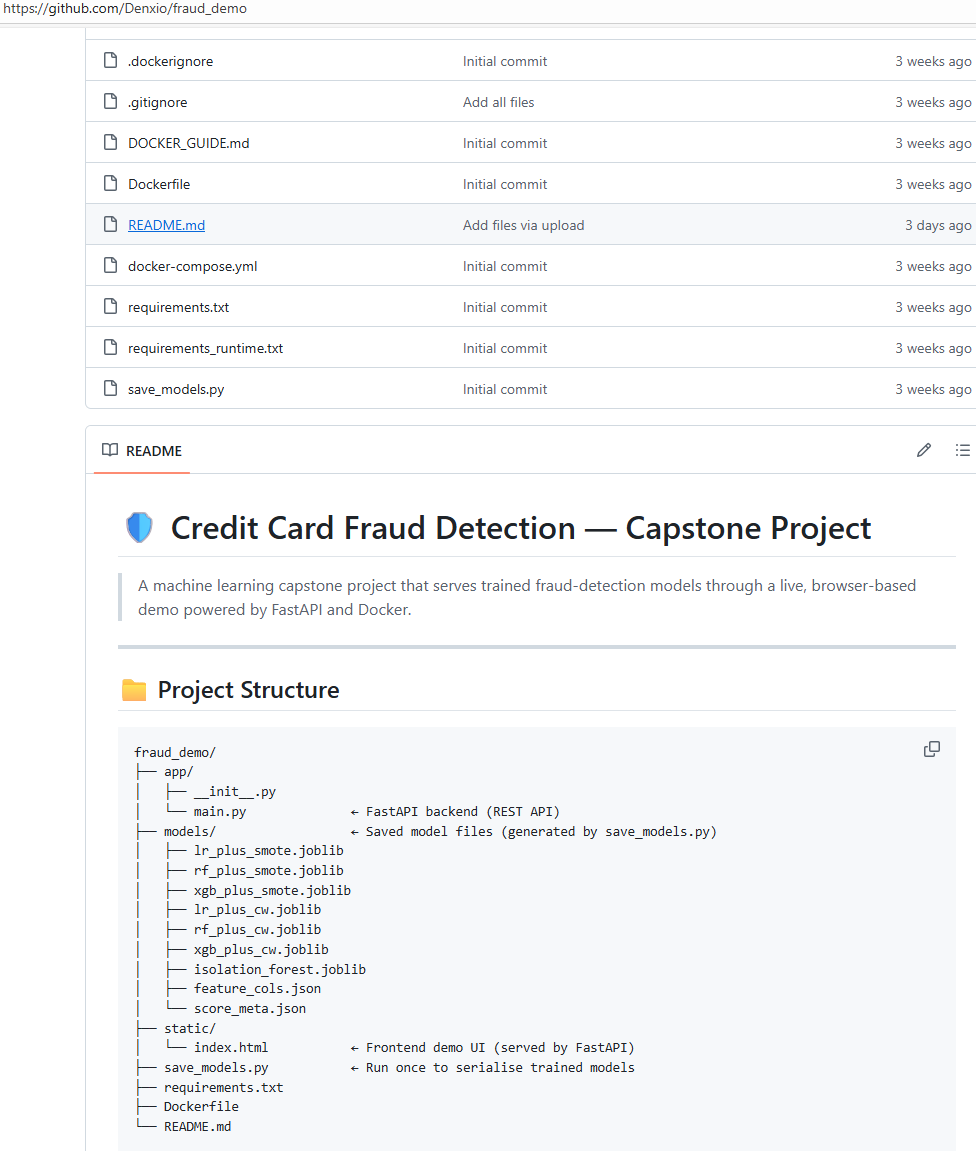



<a name="deployment-optional"></a>
# Deployment